In [220]:
import cmdstanpy
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pyreadr
from cmdstanpy import CmdStanModel
cmdstanpy.install_cmdstan();

CmdStan install directory: /Users/cwf25/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


In [221]:
seed = 739485

In [34]:
logistic_data = pyreadr.read_r('logistic_data.Rda')[None]
logistic_data.head().style.hide(axis='index')  # Only show part of the data

y,time
0.795570,0.000000
0.174560,0.500000
0.774322,1.000000
3.083851,1.500000
2.163227,2.000000


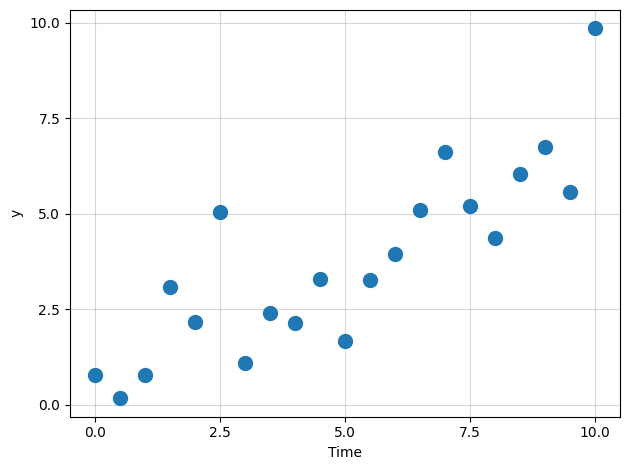

In [212]:
plt.grid(alpha=.5)
plt.scatter(logistic_data['time'], logistic_data['y'], s=100, zorder=2)
plt.xticks((0., 2.5, 5., 7.5, 10.));
plt.yticks((0., 2.5, 5., 7.5, 10.));
plt.xlabel('Time')
plt.ylabel('y')
plt.tight_layout()

In [77]:
# Only want to solve the ODE at unique times in Stan to reduce runtime
logistic_unique_times = np.sort(logistic_data['time'].unique())

# Create a dictionary of data that Stan needs to define the model using the same
# names as those in the "logistic.stan" file
stan_logistic_data = {
    'N': len(logistic_data),
    'T': len(logistic_unique_times),
    'y': logistic_data['y'],
    'time': logistic_unique_times,
    'time_idx': [np.where(logistic_unique_times == t)[0].item() + 1 for t in logistic_data['time']],
    'include_likelihood': True
}

In [78]:
fit_logistic = CmdStanModel(stan_file="logistic.stan").sample(stan_logistic_data, chains=4, seed=seed)

21:59:37 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

21:59:37 - cmdstanpy - INFO - CmdStan done processing.
21:59:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ode_rk45: ode parameters and data is inf, but must be finite! (in 'logistic.stan', line 28, column 4 to column 101)
	Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'logistic.stan', line 41, column 28 to column 63)
Consider re-running with show_console=True if the above output is unclear!


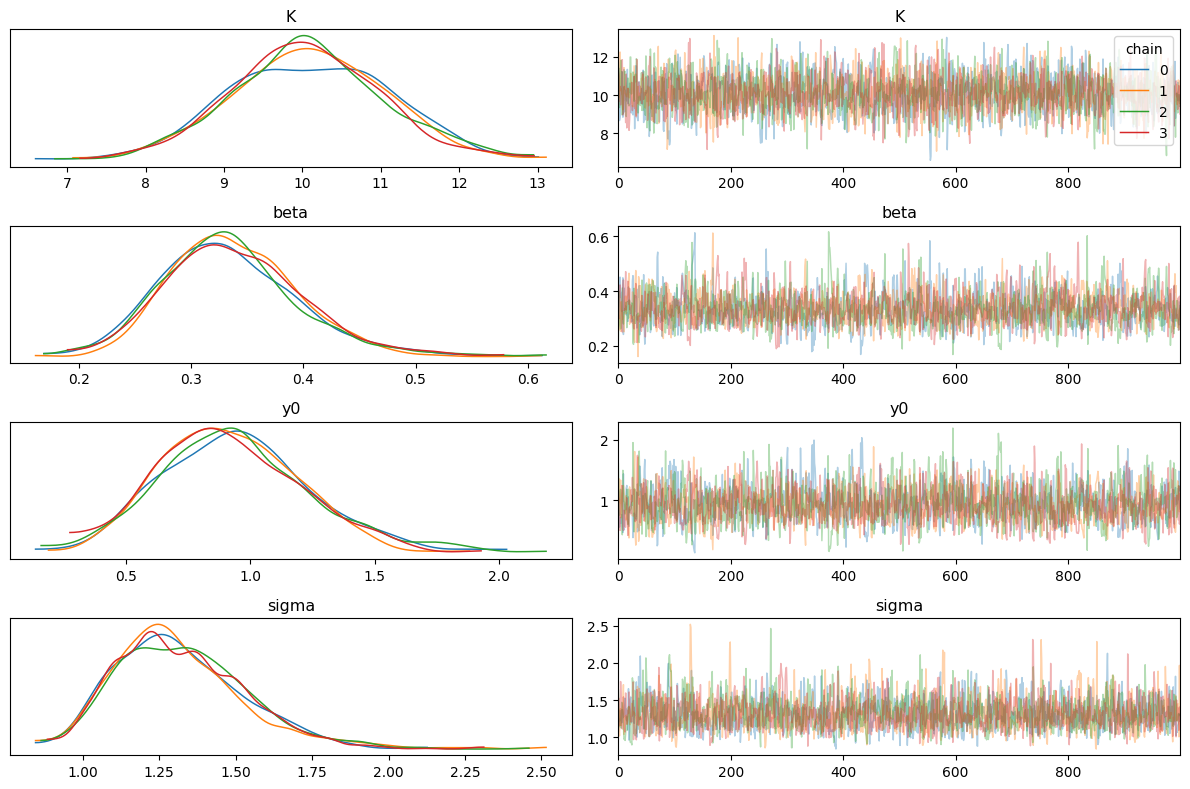

In [122]:
az.plot_trace(fit_logistic, var_names=('K', 'beta', 'y0', 'sigma'), compact=False, legend=True)
plt.tight_layout()

In [108]:
fit_logistic.summary().head()[1:]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
K,10.074000,0.018656,0.985179,0.985740,8.481330,10.067600,11.715900,2800.61,2563.57,3143.22,1.00247
beta,0.336348,0.001467,0.060165,0.056812,0.248521,0.330907,0.440571,1726.85,1928.62,1938.10,1.00132
y0,0.929317,0.006927,0.294832,0.293141,0.480840,0.912823,1.450850,1810.93,1845.16,2032.46,1.00220
sigma,1.319860,0.004517,0.213090,0.206077,1.022560,1.293140,1.700910,2287.86,2043.67,2567.74,1.00051


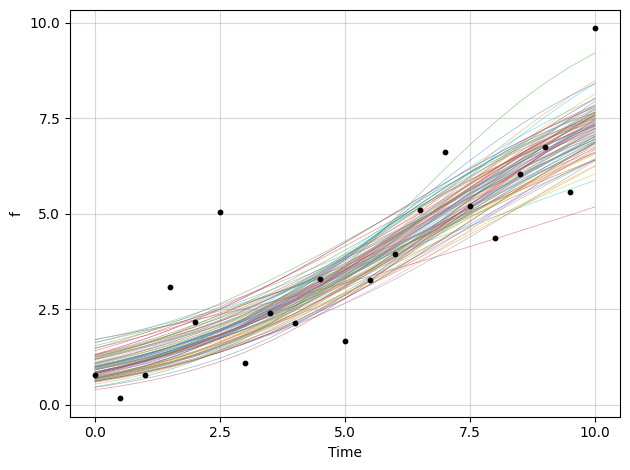

In [217]:
keys = [f'f_reps[{i}]' for i in range(1, 22)]
sample_draws = np.random.randint(0, 4000, 100)
f = fit_logistic.draws_pd()[keys].loc[sample_draws].T.to_numpy()
plt.plot(np.arange(len(f))/2, f, alpha=.5, linewidth=.5, zorder=2)
plt.grid(alpha=.5)
plt.scatter(logistic_data['time'], logistic_data['y'], c='black', s=10, zorder=2)
plt.xticks((0., 2.5, 5., 7.5, 10.));
plt.yticks((0., 2.5, 5., 7.5, 10.));
plt.xlabel('Time')
plt.ylabel('f')
plt.tight_layout()